检测到 4 个 Goal 区块


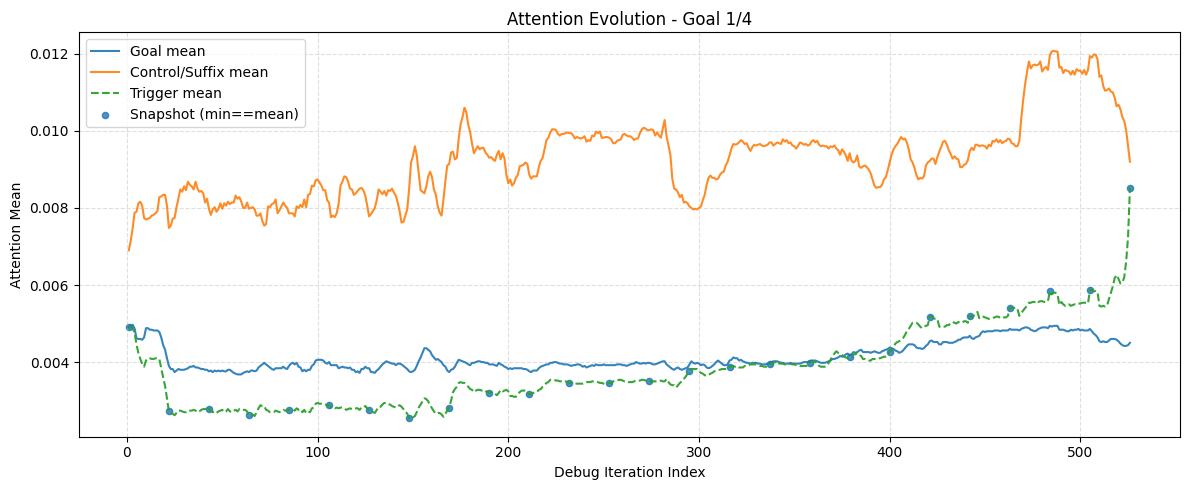

✅ Goal 1/4: 526 条注意力记录 | 快照 26 条 | 候选统计 500 条


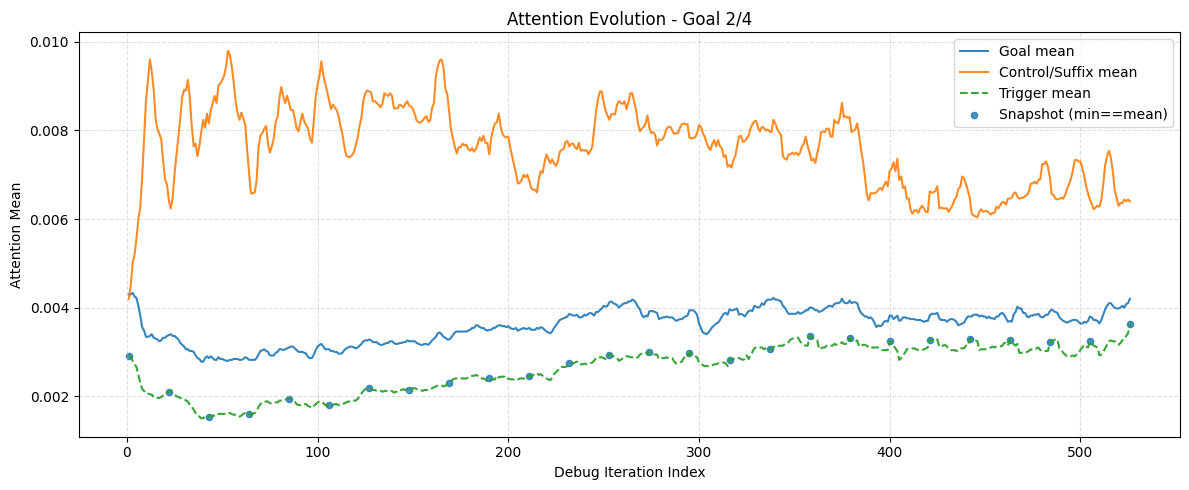

✅ Goal 2/4: 526 条注意力记录 | 快照 26 条 | 候选统计 500 条


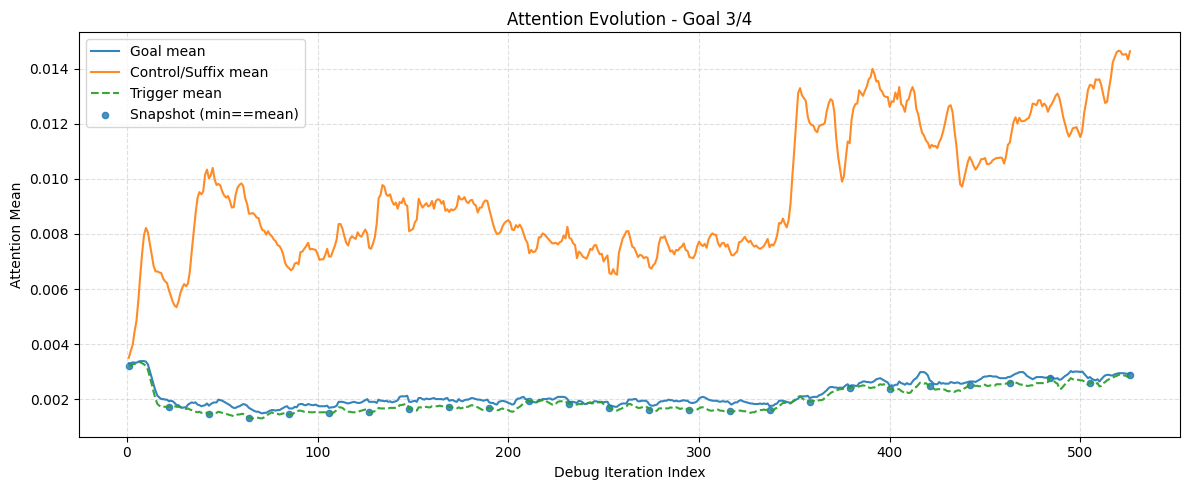

✅ Goal 3/4: 526 条注意力记录 | 快照 26 条 | 候选统计 500 条


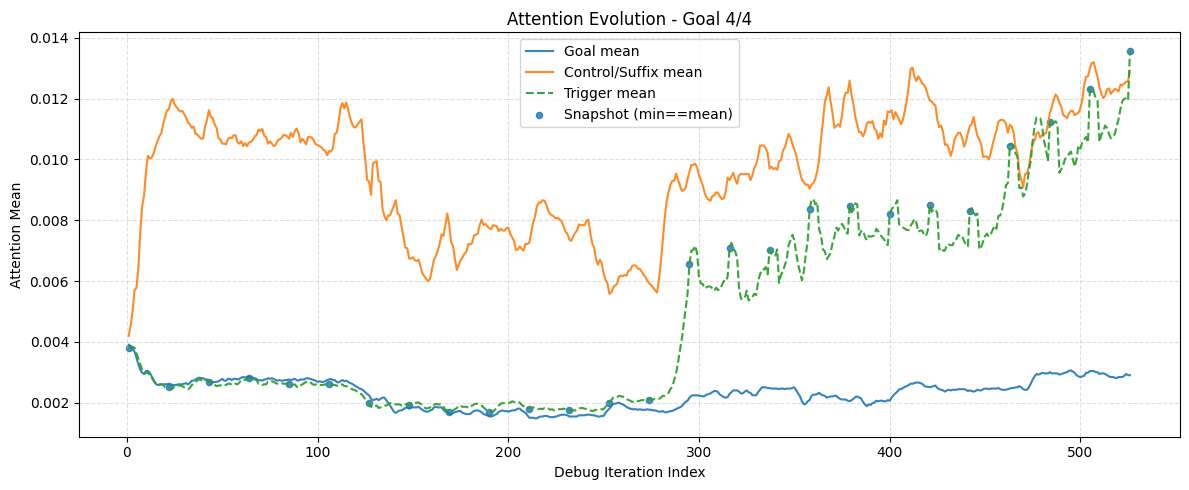

✅ Goal 4/4: 526 条注意力记录 | 快照 26 条 | 候选统计 500 条
已导出解析结果: /home/dataset/2024_zox_llm/code/AttnGCG/experiments/bash_scripts/out_gemma_2b_attngcg_direct/10_20260227_134300_attn_evolution.csv


,goal,iter_idx,goal_min,goal_mean,sys_min,sys_mean,control_min,control_mean,trigger_min,trigger_mean,is_snapshot
0,Goal 1/4,1,0.0049,0.0049,0.2148,0.2148,0.0069,0.0069,0.0049,0.0049,True
1,Goal 1/4,2,0.0045,0.0050,0.1953,0.2100,0.0060,0.0074,0.0043,0.0049,False
2,Goal 1/4,3,0.0042,0.0050,0.1904,0.2101,0.0062,0.0081,0.0040,0.0048,False
3,Goal 1/4,4,0.0031,0.0046,0.1816,0.1986,0.0062,0.0091,0.0028,0.0045,False
4,Goal 1/4,5,0.0028,0.0036,0.1797,0.2243,0.0053,0.0080,0.0025,0.0032,False


In [1]:
import os
import re

import matplotlib.pyplot as plt
import pandas as pd


NUMBER = r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?"
ATTN_PATTERN = re.compile(
    rf"\[DEBUG Attn\]\s+"
    rf"goal\(min=({NUMBER}),\s*mean=({NUMBER})\)\s*\|\s*"
    rf"sys_role\(min=({NUMBER}),\s*mean=({NUMBER})\)\s*\|\s*"
    rf"control\(min=({NUMBER}),\s*mean=({NUMBER})\)\s*\|\s*"
    rf"trigger\(min=({NUMBER}),\s*mean=({NUMBER})\)"
)
GOAL_PATTERN = re.compile(r"Goal\s+(\d+)/(\d+)")


def _split_goal_blocks(content: str):
    matches = list(GOAL_PATTERN.finditer(content))
    if not matches:
        return [("Goal 1/1", content)]

    blocks = []
    for i, m in enumerate(matches):
        start = m.start()
        end = matches[i + 1].start() if i + 1 < len(matches) else len(content)
        name = f"Goal {m.group(1)}/{m.group(2)}"
        blocks.append((name, content[start:end]))
    return blocks


def _parse_goal_block(goal_name: str, text: str, tol: float = 1e-9) -> pd.DataFrame:
    rows = []
    for idx, m in enumerate(ATTN_PATTERN.finditer(text), start=1):
        vals = [float(v) for v in m.groups()]
        g_min, g_mean, s_min, s_mean, c_min, c_mean, t_min, t_mean = vals

        # min == mean 通常是单样本评估快照；min != mean 通常是候选批量统计
        is_snapshot = (
            abs(g_min - g_mean) <= tol
            and abs(s_min - s_mean) <= tol
            and abs(c_min - c_mean) <= tol
            and abs(t_min - t_mean) <= tol
        )

        rows.append(
            {
                "goal": goal_name,
                "iter_idx": idx,
                "goal_min": g_min,
                "goal_mean": g_mean,
                "sys_min": s_min,
                "sys_mean": s_mean,
                "control_min": c_min,
                "control_mean": c_mean,
                "trigger_min": t_min,
                "trigger_mean": t_mean,
                "is_snapshot": is_snapshot,
            }
        )

    return pd.DataFrame(rows)


def plot_attention_evolution(
    log_file_path: str,
    rolling_window: int = 1,
    show_sys_role: bool = False,
    save_csv: bool = False,
):
    if not os.path.exists(log_file_path):
        raise FileNotFoundError(f"找不到日志文件: {log_file_path}")

    with open(log_file_path, "r", encoding="utf-8") as f:
        content = f.read()

    blocks = _split_goal_blocks(content)
    print(f"检测到 {len(blocks)} 个 Goal 区块")

    all_goal_dfs = []

    for goal_name, block_text in blocks:
        df = _parse_goal_block(goal_name, block_text)
        if df.empty:
            print(f"⚠️ {goal_name}: 未提取到 [DEBUG Attn]，跳过")
            continue

        all_goal_dfs.append(df)

        plot_df = df.copy()
        if rolling_window > 1:
            for col in ["goal_mean", "control_mean", "trigger_mean", "sys_mean"]:
                plot_df[col] = plot_df[col].rolling(
                    window=rolling_window, min_periods=1
                ).mean()

        fig, ax = plt.subplots(figsize=(12, 5))

        ax.plot(plot_df["iter_idx"], plot_df["goal_mean"], label="Goal mean", alpha=0.9)
        ax.plot(
            plot_df["iter_idx"],
            plot_df["control_mean"],
            label="Control/Suffix mean",
            alpha=0.9,
        )
        ax.plot(
            plot_df["iter_idx"],
            plot_df["trigger_mean"],
            label="Trigger mean",
            linestyle="--",
            alpha=0.95,
        )

        if show_sys_role:
            ax.plot(
                plot_df["iter_idx"],
                plot_df["sys_mean"],
                label="System role mean",
                alpha=0.6,
            )

        snap = plot_df[plot_df["is_snapshot"]]
        if not snap.empty:
            ax.scatter(
                snap["iter_idx"],
                snap["trigger_mean"],
                s=20,
                marker="o",
                label="Snapshot (min==mean)",
                alpha=0.8,
            )

        ax.set_title(f"Attention Evolution - {goal_name}")
        ax.set_xlabel("Debug Iteration Index")
        ax.set_ylabel("Attention Mean")
        ax.grid(True, linestyle="--", alpha=0.4)
        ax.legend()
        plt.tight_layout()
        plt.show()

        n_snapshot = int(df["is_snapshot"].sum())
        print(
            f"✅ {goal_name}: {len(df)} 条注意力记录 | 快照 {n_snapshot} 条 | 候选统计 {len(df)-n_snapshot} 条"
        )

    if not all_goal_dfs:
        print("未解析到任何可用注意力数据")
        return None

    merged_df = pd.concat(all_goal_dfs, ignore_index=True)

    if save_csv:
        out_csv = os.path.splitext(log_file_path)[0] + "_attn_evolution.csv"
        merged_df.to_csv(out_csv, index=False)
        print(f"已导出解析结果: {out_csv}")

    return merged_df


# 旧版 [DEBUG Attn] 混合曲线逻辑默认不执行。
# 如需对照分析可手动调用 plot_attention_evolution(...)
# 当前 notebook 的默认入口在下一个 cell：只画每次迭代最优后缀的 [BEST Attn] 曲线。


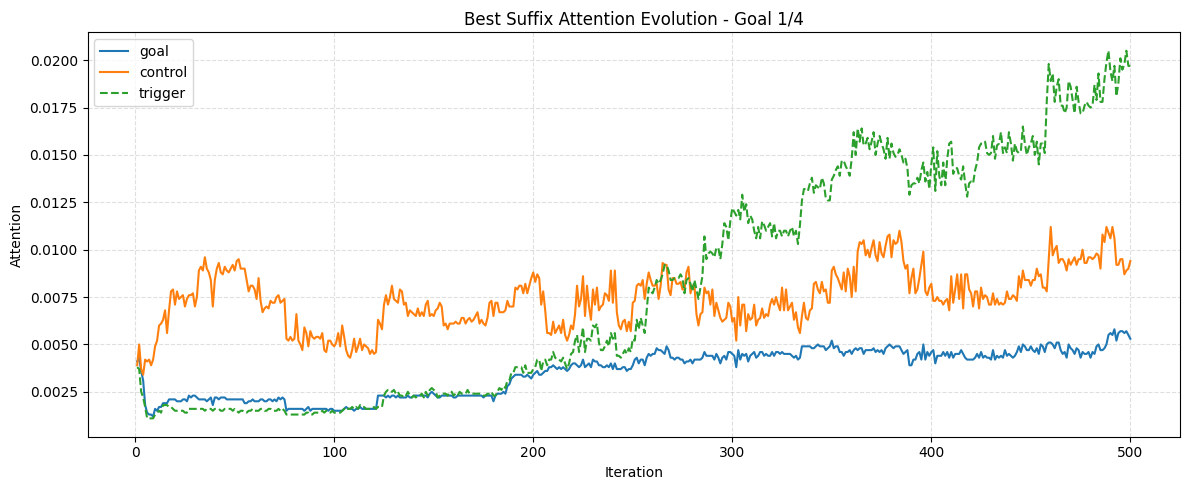

Goal 1/4: 共 500 次最优后缀记录


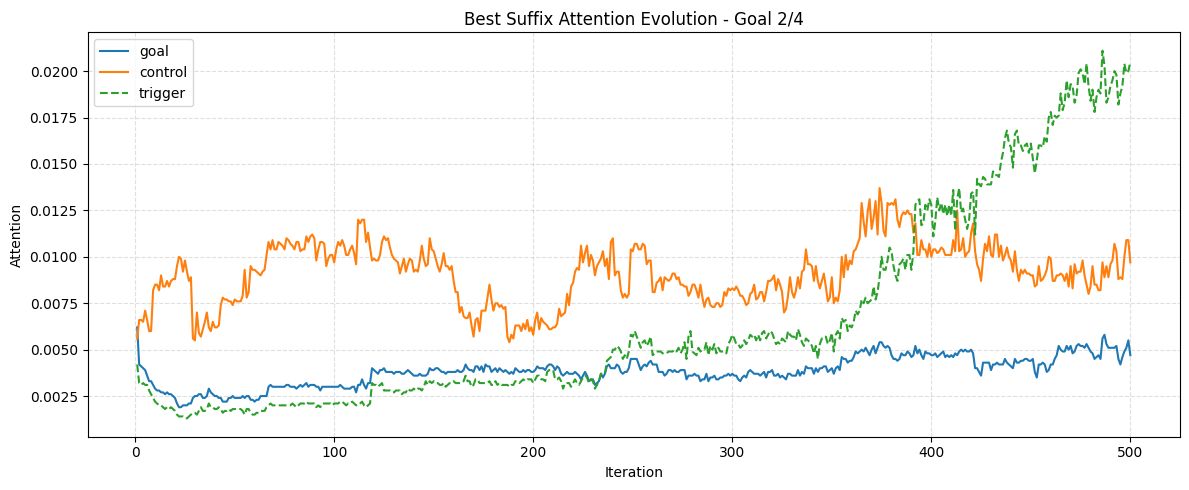

Goal 2/4: 共 500 次最优后缀记录


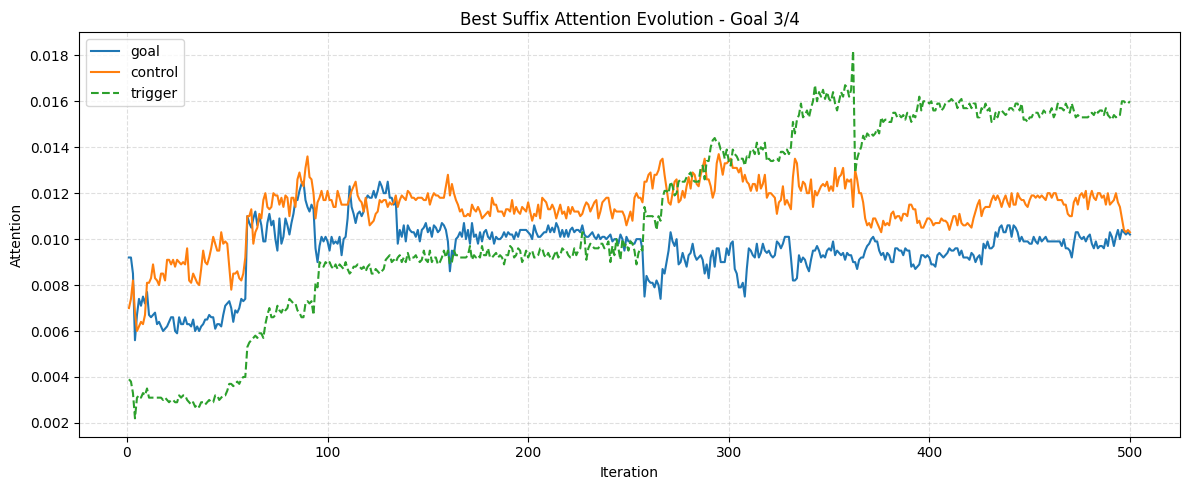

Goal 3/4: 共 500 次最优后缀记录


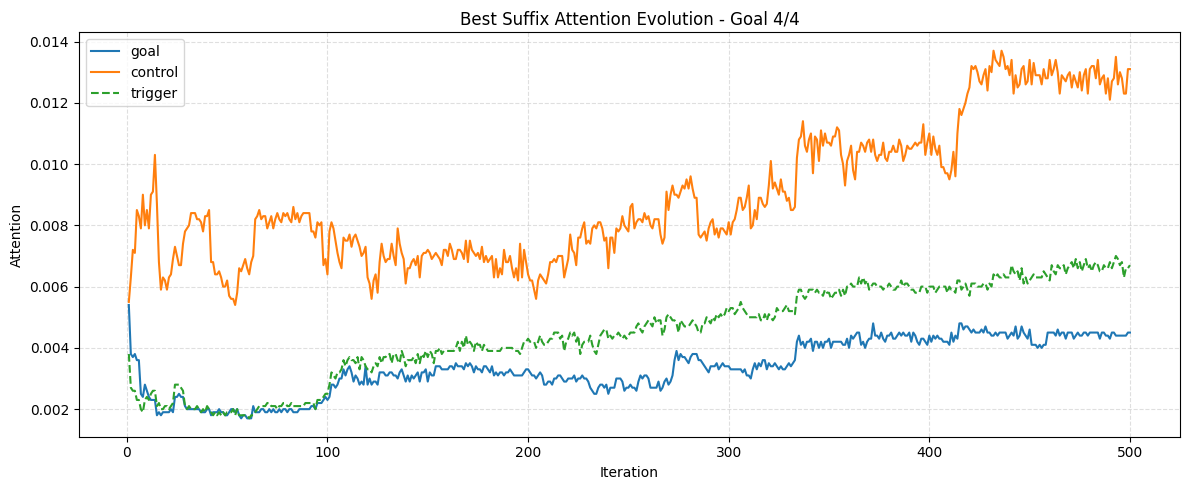

Goal 4/4: 共 500 次最优后缀记录
已导出最优后缀 attention: /home/dataset/2024_zox_llm/code/AttnGCG/experiments/bash_scripts/out_gemma_2b_attngcg_direct/30_20260228_172314_best_attn.csv


,goal,iter,goal_attn,sys_role_attn,control_attn,trigger_attn
0,Goal 1/4,1,0.0041,0.2383,0.0039,0.0038
1,Goal 1/4,2,0.0043,0.2168,0.0050,0.0037
2,Goal 1/4,3,0.0036,0.2285,0.0037,0.0025
3,Goal 1/4,4,0.0031,0.2480,0.0034,0.0022
4,Goal 1/4,5,0.0018,0.2910,0.0042,0.0017


In [8]:
import re
import matplotlib.pyplot as plt
import pandas as pd


BEST_ATTN_PATTERN = re.compile(
    r"\[BEST Attn\]\s+"
    r"goal=([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\s*\|\s*"
    r"sys_role=([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\s*\|\s*"
    r"control=([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\s*\|\s*"
    r"trigger=([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)"
)
GOAL_PATTERN = re.compile(r"Goal\s+(\d+)/(\d+)")


def parse_best_attention_only(log_file_path: str) -> pd.DataFrame:
    with open(log_file_path, "r", encoding="utf-8") as f:
        lines = f.readlines()

    current_goal = "Goal 1/1"
    rows = []
    iter_idx_by_goal = {}

    for line in lines:
        g = GOAL_PATTERN.search(line)
        if g:
            current_goal = f"Goal {g.group(1)}/{g.group(2)}"
            iter_idx_by_goal.setdefault(current_goal, 0)

        m = BEST_ATTN_PATTERN.search(line)
        if not m:
            continue

        iter_idx_by_goal.setdefault(current_goal, 0)
        iter_idx_by_goal[current_goal] += 1

        rows.append(
            {
                "goal": current_goal,
                "iter": iter_idx_by_goal[current_goal],
                "goal_attn": float(m.group(1)),
                "sys_role_attn": float(m.group(2)),
                "control_attn": float(m.group(3)),
                "trigger_attn": float(m.group(4)),
            }
        )

    return pd.DataFrame(rows)


def plot_best_attention_only(df: pd.DataFrame, rolling_window: int = 1):
    if df.empty:
        print("未找到 [BEST Attn] 日志。请使用修复后的代码重新跑实验。")
        return

    for goal_name, gdf in df.groupby("goal"):
        plot_df = gdf.sort_values("iter").copy()
        if rolling_window > 1:
            for col in ["goal_attn", "sys_role_attn", "control_attn", "trigger_attn"]:
                plot_df[col] = plot_df[col].rolling(rolling_window, min_periods=1).mean()

        plt.figure(figsize=(12, 5))
        plt.plot(plot_df["iter"], plot_df["goal_attn"], label="goal")
        # plt.plot(plot_df["iter"], plot_df["sys_role_attn"], label="sys_role", alpha=0.7)
        plt.plot(plot_df["iter"], plot_df["control_attn"], label="control")
        plt.plot(plot_df["iter"], plot_df["trigger_attn"], label="trigger", linestyle="--")
        plt.title(f"Best Suffix Attention Evolution - {goal_name}")
        plt.xlabel("Iteration")
        plt.ylabel("Attention")
        plt.grid(True, linestyle="--", alpha=0.4)
        plt.legend()
        plt.tight_layout()
        plt.show()

        print(f"{goal_name}: 共 {len(plot_df)} 次最优后缀记录")


best_log_path = "/home/dataset/2024_zox_llm/code/AttnGCG/experiments/bash_scripts/out_gemma_2b_attngcg_direct/30_20260228_172314.out"

best_df = parse_best_attention_only(best_log_path)
plot_best_attention_only(best_df, rolling_window=1)

if not best_df.empty:
    best_csv_path = best_log_path.replace(".out", "_best_attn.csv")
    best_df.to_csv(best_csv_path, index=False)
    print(f"已导出最优后缀 attention: {best_csv_path}")
    display(best_df.head())
